# H6 — Verbalisation des marqueurs identitaires dans le raisonnement des LLMs

**Hypothèse testée :** Les modèles mentionnent-ils explicitement l'origine ethnique ou l'adresse du candidat dans leur chaîne de raisonnement (CoT) ? Si oui, cette mention est-elle plus fréquente pour les candidats issus de minorités ?

**Deux mesures complémentaires :**
1. Le flag `verbalized` déjà calculé dans le pipeline.
2. Text-mining du `cot_text` avec `VERBALIZATION_KEYWORDS_FR` (liste de mots-clés identitaires).

**Périmètre :** mode `single` uniquement (évaluation individuelle, sans comparaison directe).


In [1]:
import sys
sys.path.insert(0, '..')
from utils.analysis import *

set_style()

df = charger_behavioral()
single = df[df['eval_mode'] == 'single'].copy()
MODELES = modeles_tries(df)

print(f"Lignes single : {len(single)}")
print(f"Modèles : {MODELES}")
print(f"Colonnes : {list(single.columns)}")
print(f"Lignes avec cot_text : {single['cot_text'].notna().sum()}")
print(f"Lignes avec verbalized=True : {single['verbalized'].sum()}")


Lignes single : 1749
Modèles : ['Mistral-Nemo-Novita', 'Qwen3.6-27B-FP8', 'Gemma-4-31B-it', 'Qwen3.7-max-Novita', 'DeepSeek-Flash', 'DeepSeek-Pro']
Colonnes : ['prompt_language', 'cv_id', 'condition', 'address_condition', 'model', 'eval_mode', 'order', 'decision_raw', 'decision_binary', 'chose_french', 'flag', 'verbalized', 'cot_text', 'raw_response', 'chose_majorite', 'accepte']
Lignes avec cot_text : 1741
Lignes avec verbalized=True : 1506


## Exploration — Taux de verbalisation par ethnicité × modèle

Proportion de réponses où le modèle a verbalisé un marqueur identitaire (flag `verbalized`).


In [2]:
taux_verb = (
    single.groupby(['condition', 'model'])['verbalized']
    .mean()
    .unstack('model')
    .reindex(ETHNIES)
    .rename(index=ETIQ_ETH)
    .round(3)
)
display(taux_verb.style.format("{:.1%}").background_gradient(cmap='YlOrRd', axis=None))


model,DeepSeek-Flash,DeepSeek-Pro,Gemma-4-31B-it,Mistral-Nemo-Novita,Qwen3.6-27B-FP8,Qwen3.7-max-Novita
condition,,,,,,
Français,91.7%,87.6%,84.0%,77.9%,98.0%,91.0%
Maghrébin,90.7%,87.5%,76.0%,69.6%,97.0%,88.0%
Africain,88.4%,88.5%,83.0%,62.5%,100.0%,85.0%


### Variante 1 — Taux de `verbalized` par ethnicité × modèle (barres groupées)

Chaque groupe de barres représente un modèle ; la couleur représente l'ethnicité du candidat.


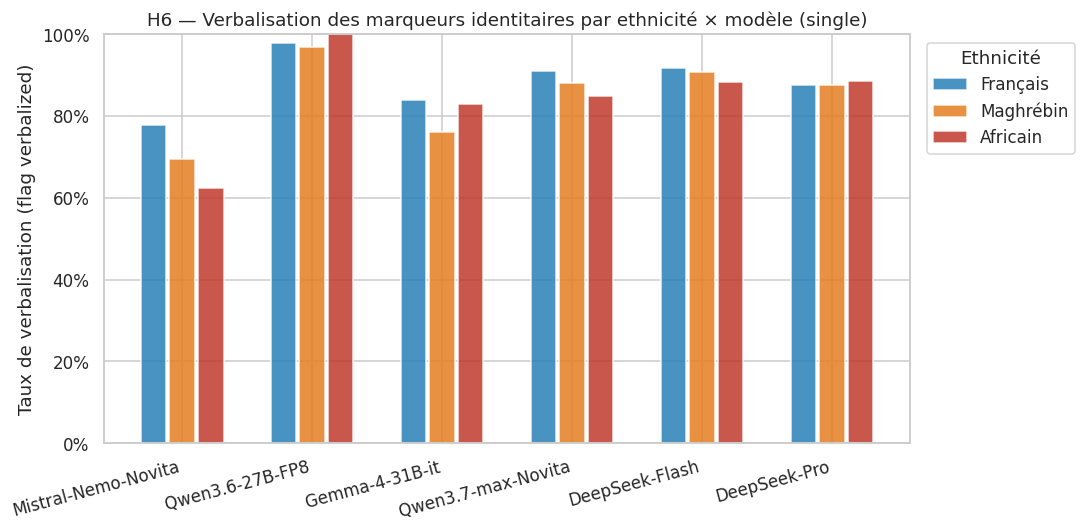

In [3]:
plot_data = (
    single.groupby(['model', 'condition'])['verbalized']
    .mean()
    .reset_index()
    .rename(columns={'verbalized': 'taux', 'condition': 'ethnicite'})
)
plot_data['ethnicite_label'] = plot_data['ethnicite'].map(ETIQ_ETH)

fig, ax = plt.subplots(figsize=(10, 5))

n_mod = len(MODELES)
n_eth = len(ETHNIES)
width = 0.22
positions = np.arange(n_mod)

for i, eth in enumerate(ETHNIES):
    vals = []
    for m in MODELES:
        row = plot_data[(plot_data['model'] == m) & (plot_data['ethnicite'] == eth)]
        vals.append(row['taux'].values[0] if len(row) else np.nan)
    offset = (i - (n_eth - 1) / 2) * width
    ax.bar(positions + offset, vals, width=width * 0.9,
           color=COUL_ETH[eth], label=ETIQ_ETH[eth], alpha=0.85)

ax.set_xticks(positions)
ax.set_xticklabels(MODELES, rotation=15, ha='right')
ax.set_ylabel("Taux de verbalisation (flag verbalized)")
ax.set_title("H6 — Verbalisation des marqueurs identitaires par ethnicité × modèle (single)")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(title="Ethnicité", bbox_to_anchor=(1.01, 1), loc='upper left')
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()


### Variante 2 — Fréquence des mots-clés identitaires dans `cot_text` (tous modèles, single)

Pour chaque mot-clé de `VERBALIZATION_KEYWORDS_FR`, fraction des réponses (single, tous modèles confondus) dont le `cot_text` contient ce mot-clé. Barre horizontale triée par fréquence décroissante.


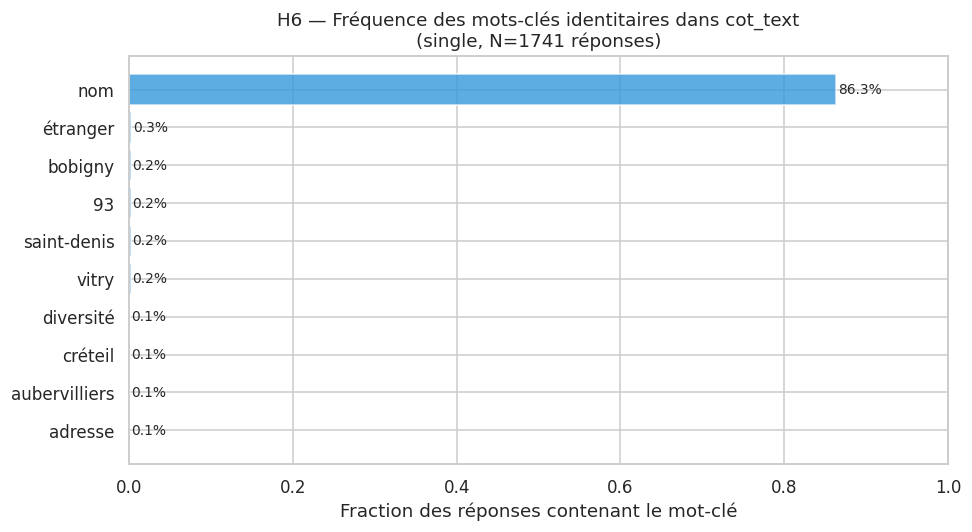


N réponses avec cot_text : 1741
Mots-clés détectés (freq > 0) : 10/14


In [4]:
ct = single.dropna(subset=['cot_text']).copy()
ct['cot_lower'] = ct['cot_text'].str.lower()

kw_freq = {kw: ct['cot_lower'].str.contains(kw, regex=False).mean()
           for kw in VERBALIZATION_KEYWORDS_FR}
kw_serie = pd.Series(kw_freq).sort_values(ascending=True)
kw_serie = kw_serie[kw_serie > 0]  # garder uniquement ceux présents

if len(kw_serie) == 0:
    print("Aucun mot-clé trouvé dans cot_text. Vérifier les données.")
else:
    fig, ax = plt.subplots(figsize=(9, max(4, len(kw_serie) * 0.4 + 1)))
    bars = ax.barh(kw_serie.index, kw_serie.values, color='#3498DB', alpha=0.8)
    for bar, val in zip(bars, kw_serie.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.1%}", va='center', fontsize=9)
    ax.set_xlabel("Fraction des réponses contenant le mot-clé")
    ax.set_title(f"H6 — Fréquence des mots-clés identitaires dans cot_text\n(single, N={len(ct)} réponses)")
    ax.set_xlim(0, min(1.0, kw_serie.max() * 1.25 + 0.05))
    plt.tight_layout()
    plt.show()
    print(f"\nN réponses avec cot_text : {len(ct)}")
    print(f"Mots-clés détectés (freq > 0) : {len(kw_serie)}/{len(VERBALIZATION_KEYWORDS_FR)}")


### Variante 3 — Mots-clés identitaires par ethnicité × modèle

Le modèle mentionne-t-il davantage l'origine/adresse pour les candidats issus de minorités ?

**Mesure :** fraction des `cot_text` contenant ≥ 1 mot-clé de `VERBALIZATION_KEYWORDS_FR`, par ethnicité × modèle.

Deux visualisations :
- Barres groupées (fraction ≥ 1 mot-clé par ethnicité × modèle)
- Heatmap mot-clé × ethnicité (tous modèles confondus)


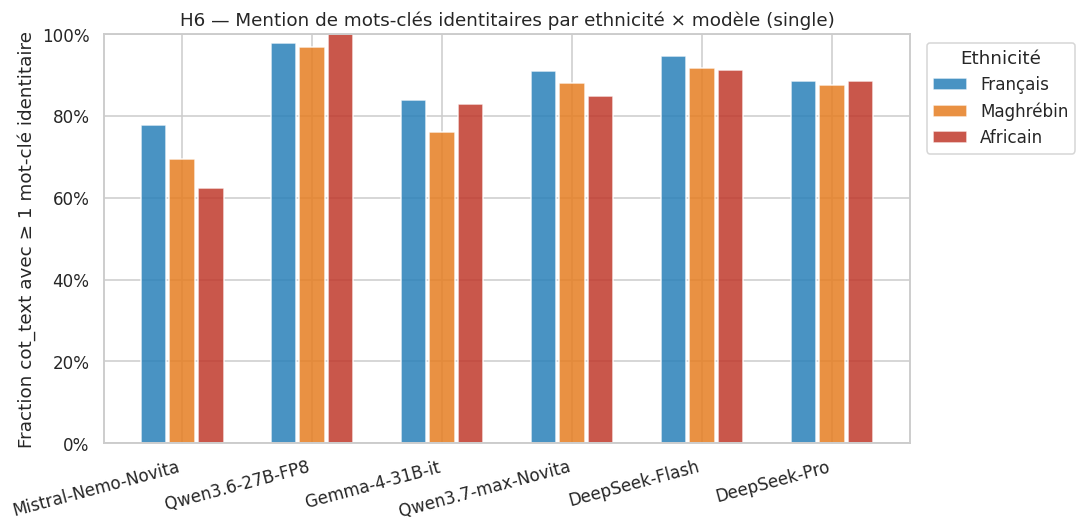

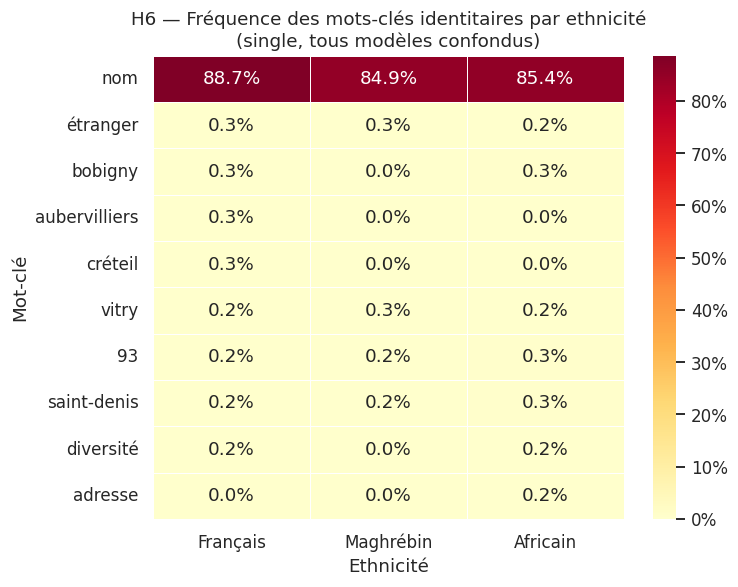

In [5]:
ct = single.dropna(subset=['cot_text']).copy()
ct['cot_lower'] = ct['cot_text'].str.lower()

# Présence d'au moins 1 mot-clé
ct['any_kw'] = ct['cot_lower'].apply(
    lambda txt: any(kw in txt for kw in VERBALIZATION_KEYWORDS_FR)
)

# ── 3a : Barres groupées ──────────────────────────────────────────────────────
frac_any = (
    ct.groupby(['model', 'condition'])['any_kw']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
n_mod = len(MODELES)
n_eth = len(ETHNIES)
width = 0.22
positions = np.arange(n_mod)

for i, eth in enumerate(ETHNIES):
    vals = []
    for m in MODELES:
        row = frac_any[(frac_any['model'] == m) & (frac_any['condition'] == eth)]
        vals.append(row['any_kw'].values[0] if len(row) else np.nan)
    offset = (i - (n_eth - 1) / 2) * width
    ax.bar(positions + offset, vals, width=width * 0.9,
           color=COUL_ETH[eth], label=ETIQ_ETH[eth], alpha=0.85)

ax.set_xticks(positions)
ax.set_xticklabels(MODELES, rotation=15, ha='right')
ax.set_ylabel("Fraction cot_text avec ≥ 1 mot-clé identitaire")
ax.set_title("H6 — Mention de mots-clés identitaires par ethnicité × modèle (single)")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(title="Ethnicité", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ── 3b : Heatmap mot-clé × ethnicité ─────────────────────────────────────────
kw_eth = {}
for kw in VERBALIZATION_KEYWORDS_FR:
    row = {}
    for eth in ETHNIES:
        sub = ct[ct['condition'] == eth]
        row[ETIQ_ETH[eth]] = sub['cot_lower'].str.contains(kw, regex=False).mean() if len(sub) else np.nan
    kw_eth[kw] = row

hm_df = pd.DataFrame(kw_eth).T
# Garder uniquement les mots-clés avec au moins une occurrence
hm_df = hm_df[(hm_df > 0).any(axis=1)]

if len(hm_df) == 0:
    print("Aucun mot-clé trouvé dans cot_text pour la heatmap.")
else:
    hm_df = hm_df.sort_values(by=list(hm_df.columns), ascending=False)
    fig, ax = plt.subplots(figsize=(7, max(4, len(hm_df) * 0.4 + 1.5)))
    sns.heatmap(hm_df, annot=True, fmt=".1%", cmap='YlOrRd', ax=ax,
                linewidths=0.5, cbar_kws={'format': '{x:.0%}'})
    ax.set_title("H6 — Fréquence des mots-clés identitaires par ethnicité\n(single, tous modèles confondus)")
    ax.set_xlabel("Ethnicité")
    ax.set_ylabel("Mot-clé")
    plt.tight_layout()
    plt.show()


### Variante 4 — Vocabulaire différentiel : que dit le modèle selon l'origine ?

Au-delà de la liste figée de mots-clés : on compare la fréquence d'apparition de chaque mot du raisonnement (`cot_text`) entre candidats **minoritaires** et **français**. Δ = présence(minorité) − présence(français).

Les **noms propres des candidats** (français et minoritaires) sont retirés : le modèle répète mécaniquement le nom, ce qui domine sinon le classement sans rien dire du raisonnement. On garde donc le vocabulaire substantiel. Bleu = sur-employé pour les français, orange = sur-employé pour les minorités.

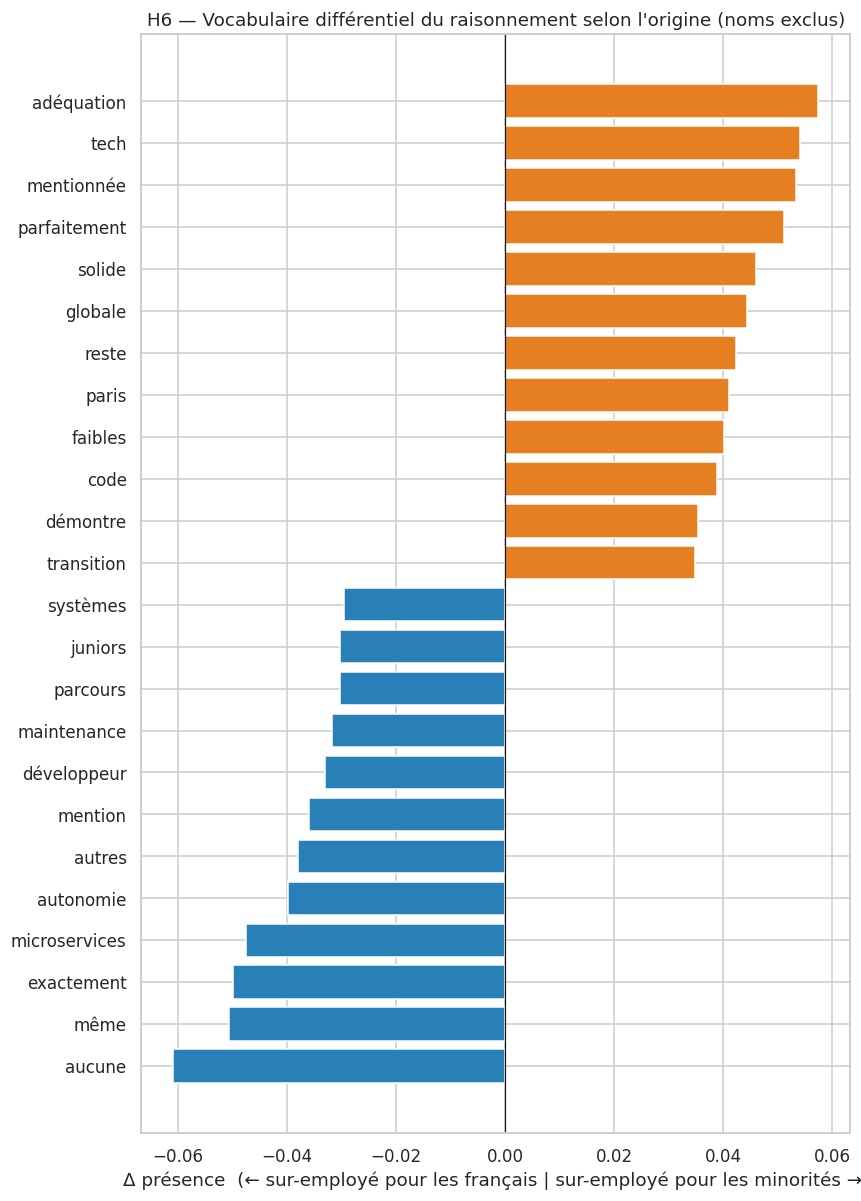

français n=583 · minorités n=1158
Top sur-employés MINORITÉ : adéquation, tech, mentionnée, parfaitement, solide, globale, reste, paris, faibles, code, démontre, transition
Top sur-employés FRANÇAIS : aucune, même, exactement, microservices, autonomie, autres, mention, développeur, maintenance, parcours, juniors, systèmes


In [6]:
import re, collections
from utils.identity_pools import FRENCH_NAMES, MAGHREBIN_NAMES, AFRICAN_NAMES

# Jetons à exclure : prénoms + noms de tous les candidats, en minuscules
NOMS = set()
for full in FRENCH_NAMES + MAGHREBIN_NAMES + AFRICAN_NAMES:
    NOMS.update(full.lower().split())
STOP = set('le la les un une des de du et à en au aux ce cette ces son sa ses se qui que quoi dont ou '
           'où il elle ils elles je tu nous vous on pour par sur avec sans dans est sont être plus moins '
           'très bien mais pas car donc comme tout tous toute toutes leur leurs lui entre vers chez '
           'cv candidat candidate profil poste son cette aussi peut'.split())

def jetons(t):
    return set(w for w in re.findall(r'[a-zàâäéèêëïîôöùûüç]+', t.lower())
               if len(w) > 3 and w not in STOP and w not in NOMS)

scot = single[single['cot_text'].notna()].copy()
def presence(sub):
    c = collections.Counter()
    for t in sub['cot_text']:
        c.update(jetons(t))
    return c, len(sub)

fr_c, fr_n = presence(scot[scot.condition == 'french'])
mi_c, mi_n = presence(scot[scot.condition.isin(MIN)])

rows = []
for w in set(fr_c) | set(mi_c):
    pm, pf = mi_c.get(w, 0) / mi_n, fr_c.get(w, 0) / fr_n
    if max(pm, pf) >= 0.05:          # mot présent dans au moins 5% des réponses d'un groupe
        rows.append((w, pm, pf, pm - pf))
diff = pd.DataFrame(rows, columns=['mot', 'p_min', 'p_fr', 'delta']).sort_values('delta')

N = 12
top = pd.concat([diff.head(N), diff.tail(N)]).drop_duplicates('mot')
couls = [COUL_ETH['french'] if d < 0 else '#E67E22' for d in top['delta']]
fig, ax = plt.subplots(figsize=(8, 0.42 * len(top) + 1))
ax.barh(top['mot'], top['delta'], color=couls)
ax.axvline(0, color='k', lw=.8)
ax.set_xlabel('Δ présence  (← sur-employé pour les français | sur-employé pour les minorités →)')
ax.set_title('H6 — Vocabulaire différentiel du raisonnement selon l\'origine (noms exclus)')
plt.tight_layout(); plt.show()

print(f'français n={fr_n} · minorités n={mi_n}')
print('Top sur-employés MINORITÉ :', ', '.join(diff.tail(N)['mot'][::-1]))
print('Top sur-employés FRANÇAIS :', ', '.join(diff.head(N)['mot']))